## 1. Data Reading

- PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often - family members, but not always.
- HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
- CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- Destination - The planet the passenger will be debarking to.
- Age - The age of the passenger.
- VIP - Whether the passenger has paid for special VIP service during the voyage.
- RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- Name - The first and last names of the passenger.
- Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

In [899]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('./dataset/train.csv')
test = pd.read_csv('./dataset/test.csv')
train.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


### Target data of distribution

<Axes: xlabel='Transported', ylabel='count'>

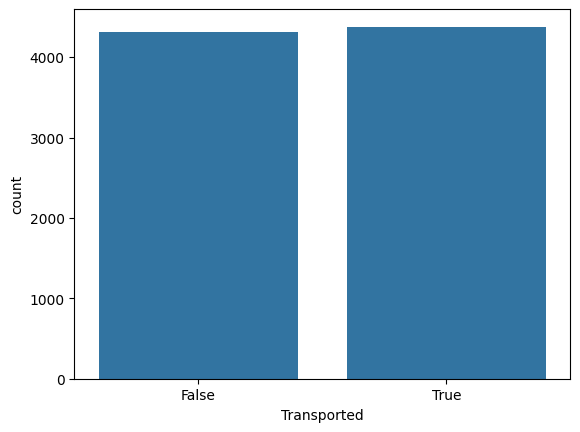

In [900]:
target = train['Transported']
sns.countplot(x = target)

In [901]:
np.round(len(train.iloc[train['Transported'] == 1]) / len(train['Transported']), 4)

np.float64(0.5036)

ratio of true of target data is 50.36%. We don't need Data Augmentation

### Null of Dataset

In [902]:
train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

### Check duplicated values

In [903]:
train.duplicated().sum()

np.int64(0)

There is no duplicated values

### Cardinality

In [904]:
train.nunique()

PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2
dtype: int64

### Data types

In [905]:
train.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

1. Numerical data 
- Age
- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck
2. Categorial data (One-Hot encoding)
- PassengerId
- HomePlanet
- Cryosleep
- Cabin
- Destination
- VIP
- Name

## 2. EDA

### Age distribution

<Axes: xlabel='Age', ylabel='Count'>

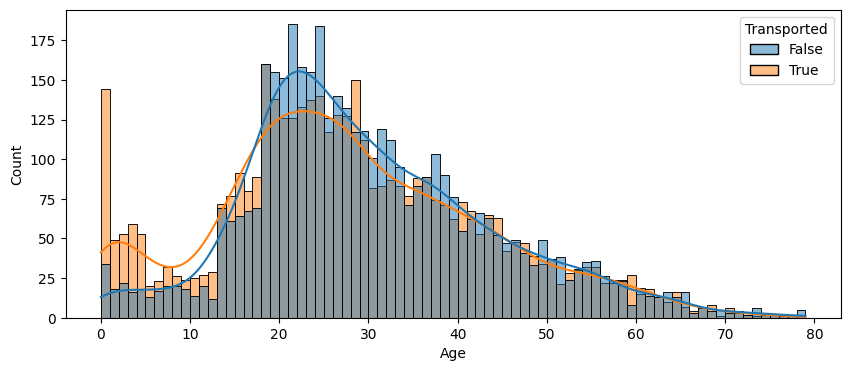

In [906]:
fig = plt.figure(figsize=(10, 4))
sns.histplot(x=train['Age'], hue=train['Transported'], binwidth=1, kde=True)

While the 18-and-under group showed more 'True' cases, 'False' results predominated in the 19 to 40 age bracket

- Notes
1. New feature "Age_group" (1 to 18, 19 to 40, 40 ~) is needed

### Expenditure distribution

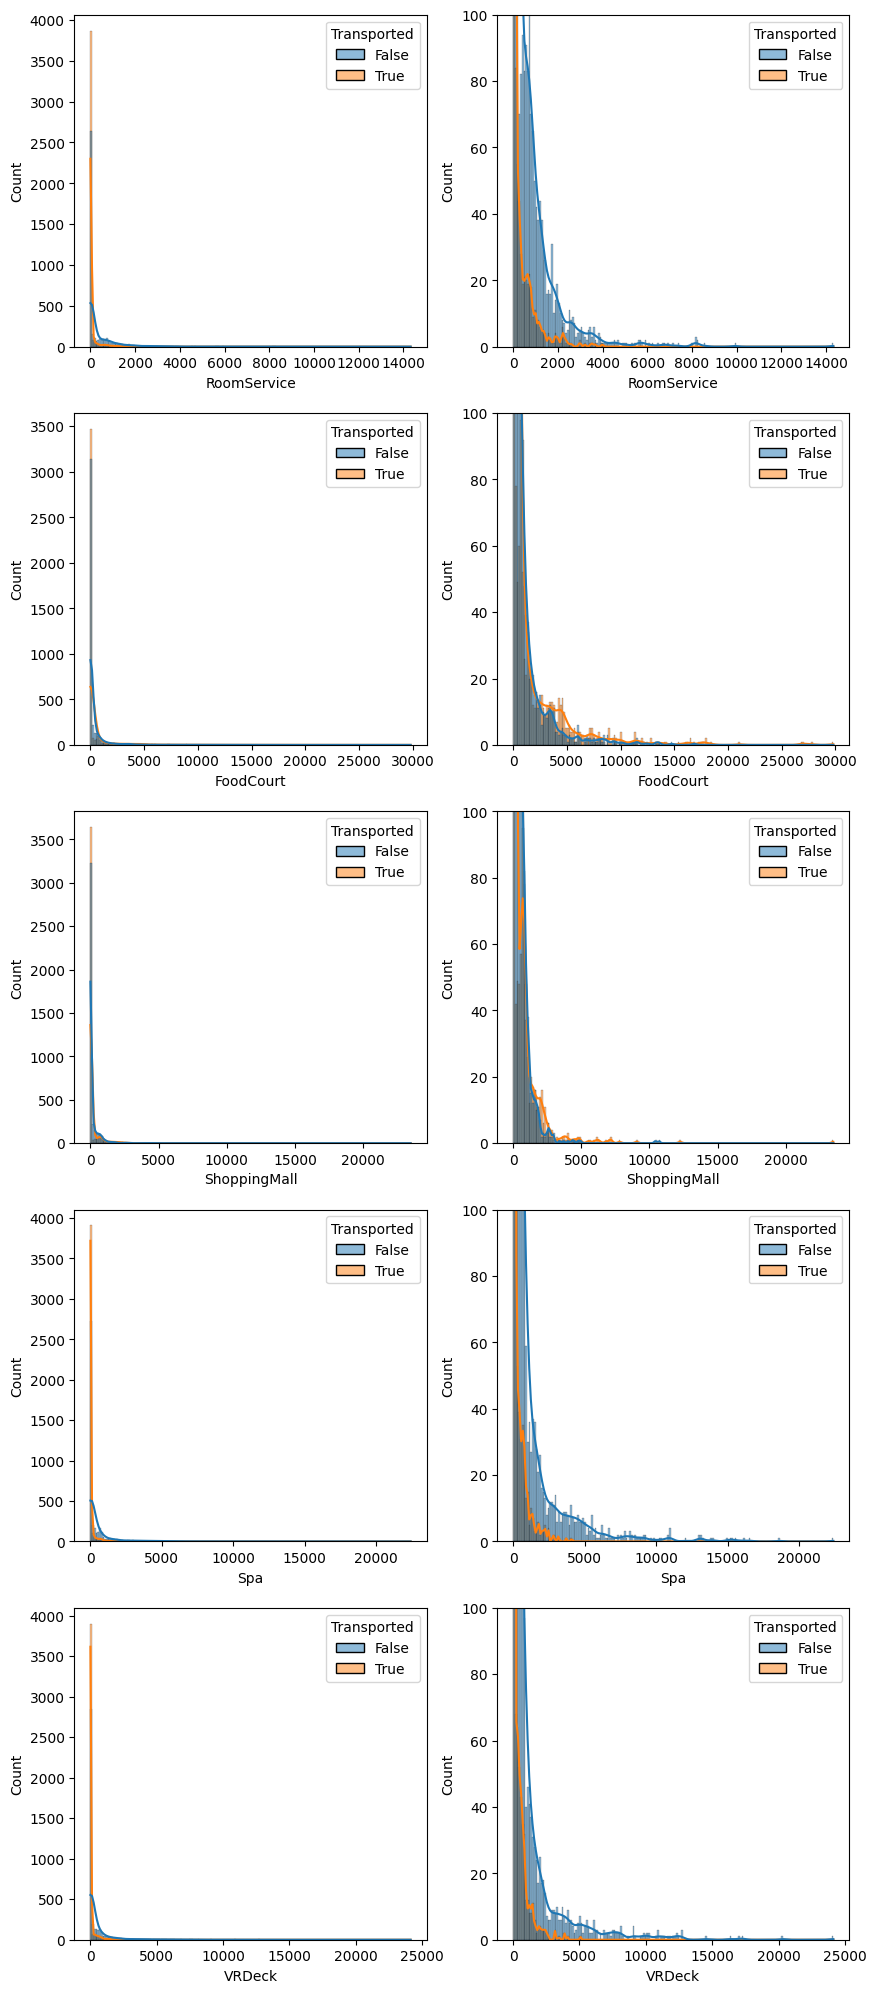

In [907]:
expenditure = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(5, 2, figsize=(10, 25))
axes_list = axes.flatten()

for i, exp in enumerate(expenditure):
    sns.histplot(x=train[exp], ax=axes_list[2*i], kde=True, hue=train['Transported'])

    plt.ylim(0, 1)
    sns.histplot(x=train[exp], ax=axes_list[2*i + 1], kde=True, hue=train['Transported'])
    axes_list[2*i + 1].set_ylim(0, 100)    
    

Notes:
- The majority of passengers had zero expenditure.
- "Since non-spending passengers show higher survival rates, we should engineer a new feature, 'No_spending'"
- There are a small number of outliers
- RoomService, Spa and VRDeck have different distributions to FoodCourt and ShoppingMall

Insight:
- create new feature "total_expenditure"
- create new feature "No_spending"
- Create "Essential" / "Luxury" → "Categorize spending into 'Essential' (FoodCourt, ShoppingMall) and 'Luxury' (RoomService, Spa, VRDeck) to capture different consumption patterns.
- Take the log transform to reduce skew


### PassengerId

In [908]:
train['PassengerId'].head(5)

0    0001_01
1    0002_01
2    0003_01
3    0003_02
4    0004_01
Name: PassengerId, dtype: str

- Notes
1. passengerId takes the form gggg_pp.
2. we can extract group_number and group_size
3. If group_size is 1, we can create new feature 'Solo'

### HomePlanet

<Axes: xlabel='HomePlanet', ylabel='count'>

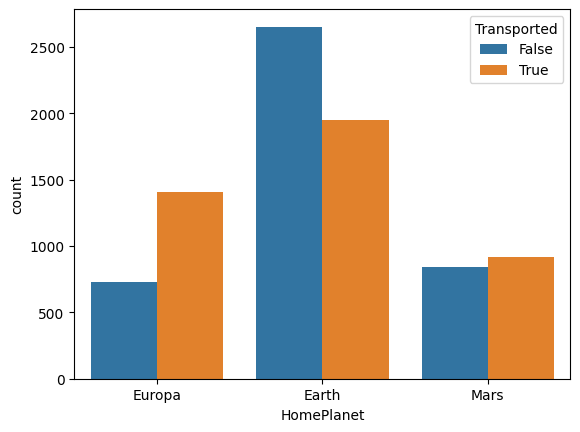

In [909]:
sns.countplot(x = train['HomePlanet'], hue=train['Transported'])

In [910]:
train.groupby(['HomePlanet'])['Transported'].mean()

HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64

- Notes
1. 65% of passengers from Europa was transported
2. 42% of passengers from Earth was not transported

### CryoSleep

<Axes: xlabel='CryoSleep', ylabel='count'>

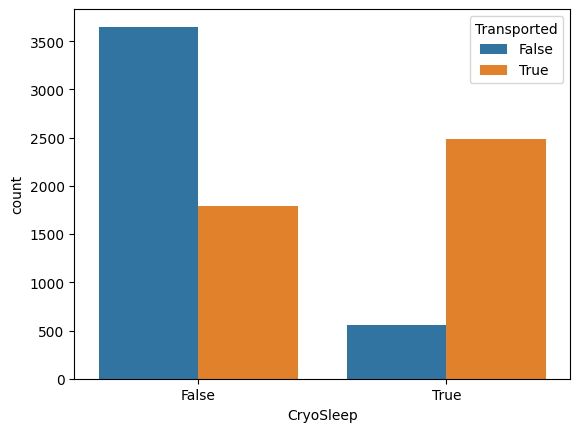

In [911]:
sns.countplot(x=train['CryoSleep'], hue=train['Transported'])

In [912]:
train.groupby(train['CryoSleep'])['Transported'].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

- Notes
1. 81% of passengers in CryoSleep was transported (It is very important information)


### Cabin

In [913]:
train['Cabin'].head(5)

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: str

- Notes
1. Cabin takes the form deck/num/side. So we can extract Cabin to cabin_deck, cabin_num, cabin_side
2. cabin_side has two values P, S

### Destination

<Axes: xlabel='Destination', ylabel='count'>

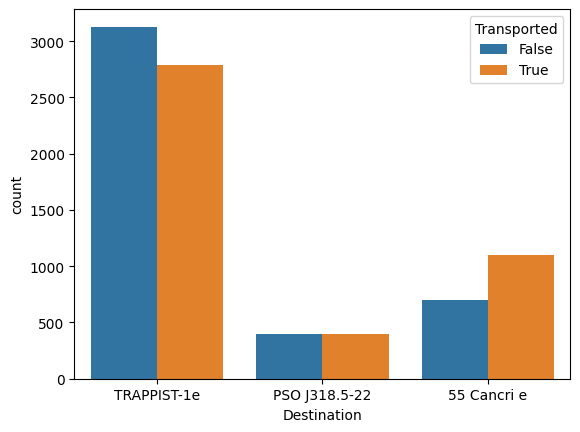

In [914]:
sns.countplot(x=train['Destination'], hue=train['Transported'])

### VIP

<Axes: xlabel='VIP', ylabel='count'>

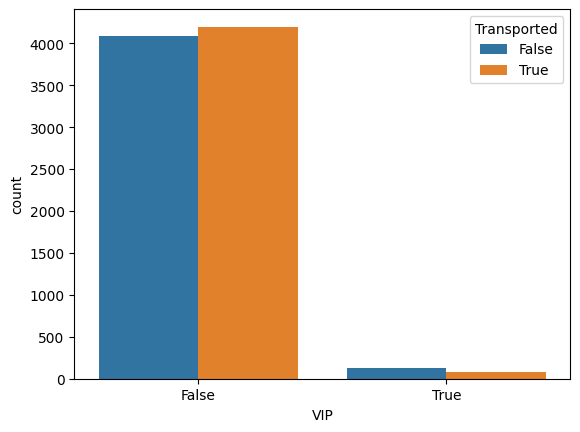

In [915]:
sns.countplot(x=train['VIP'], hue=train['Transported'])

In [916]:
len(train.loc[train['VIP'] == False]) / len(train)

0.9537558955481422

In [917]:
train.groupby(train['VIP'])['Transported'].mean()

VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

- Notes

The 'VIP' feature is not very informative because the vast majority of passengers are non-VIPs, and the transportation rate among them is nearly identical

So we can drop it

### Name

In [918]:
train['Name'].head(10)

0       Maham Ofracculy
1          Juanna Vines
2         Altark Susent
3          Solam Susent
4     Willy Santantines
5     Sandie Hinetthews
6    Billex Jacostaffey
7    Candra Jacostaffey
8         Andona Beston
9        Erraiam Flatic
Name: Name, dtype: str

- Notes
1. We can extract the 'Surname' from the 'Name' feature
2. It is assumed that passengers with the same surname belong to the same family

- Insight
1. we can create new feature 'Family_size' with 'Surname'

# 3 Feature Engeeniering

### create Age_group

In [919]:
train['Age_group'] = None
train.loc[train['Age'] < 19, 'Age_group'] = 'under19'
train.loc[(train['Age'] >= 19) & (train['Age'] <= 40), 'Age_group'] = '19to40'
train.loc[train['Age'] > 40, 'Age_group'] = "over40"

test['Age_group'] = None
test.loc[test['Age'] < 19, 'Age_group'] = 'under19'
test.loc[(test['Age'] >= 19) & (test['Age'] <= 40), 'Age_group'] = '19to40'
test.loc[test['Age'] > 40, 'Age_group'] = "over40"

<Axes: xlabel='Age_group', ylabel='count'>

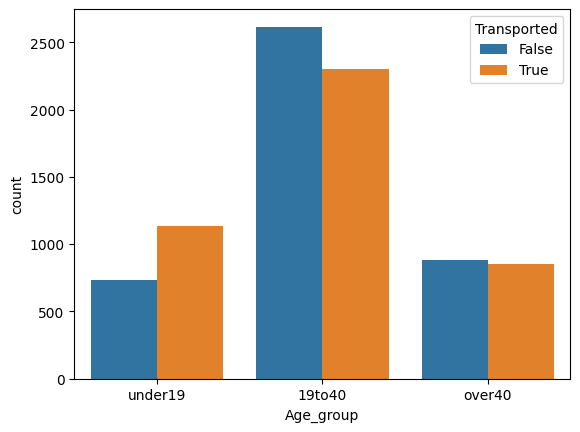

In [920]:
sns.countplot(x=train['Age_group'], hue=train['Transported'], order=['under19', '19to40', 'over40'])

### create total_speding & No_spending

In [921]:
# total_spending
train['Total_expenditure'] = train[expenditure].sum(axis=1)
test['Total_expenditure'] = test[expenditure].sum(axis=1)

# No_spending
train['No_spending'] = (train['Total_expenditure'] == 0).astype(int)
test['No_spending'] = (test['Total_expenditure'] == 0).astype(int)

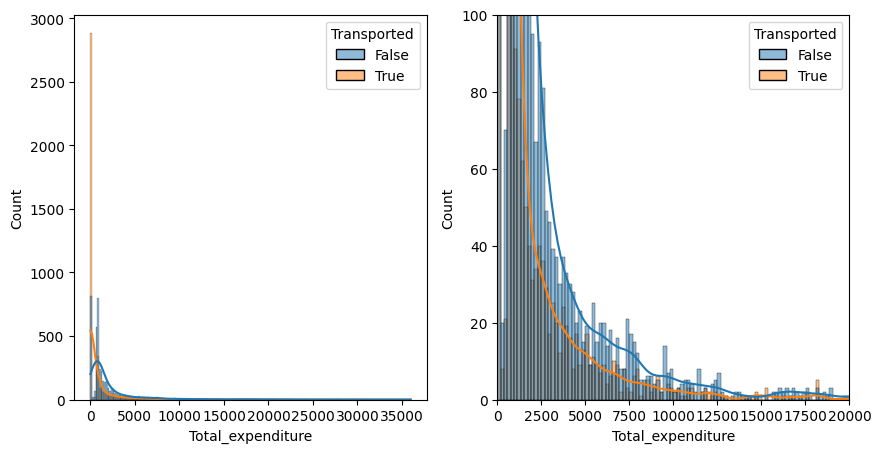

In [922]:
# total_spending distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i in range(len(axes)):
    sns.histplot(x=train['Total_expenditure'], hue=train['Transported'], ax=axes[i], kde=True)
    axes[1].set_xlim(0, 20000)
    axes[1].set_ylim(0, 100)

<Axes: xlabel='No_spending', ylabel='count'>

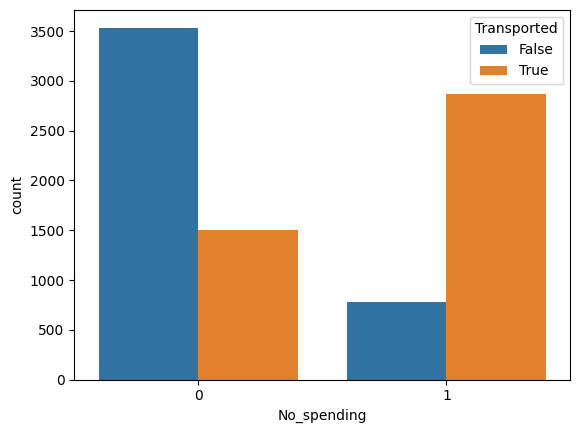

In [923]:
# No_spending distribution

sns.countplot(x=train['No_spending'], hue=train['Transported'])

In [924]:
train.groupby(['No_spending'])['Transported'].mean()

No_spending
0    0.298611
1    0.786477
Name: Transported, dtype: float64

### Luxury & essential

In [925]:
luxury = ['RoomService', 'Spa', 'VRDeck']
essential = ['ShoppingMall', 'FoodCourt']

train['Luxury_spending'] = (train[luxury].sum(axis=1) != 0).astype(int)
train['Essential_spending'] = (train[essential].sum(axis=1) != 0).astype(int)

test['Luxury_spending'] = (test[luxury].sum(axis=1) != 0).astype(int)
test['Essential_spending'] = (test[essential].sum(axis=1) != 0).astype(int)

Luxury_spending  Essential_spending
0                0                     0.786477
                 1                     0.647059
1                0                     0.131535
                 1                     0.305209
Name: Transported, dtype: float64


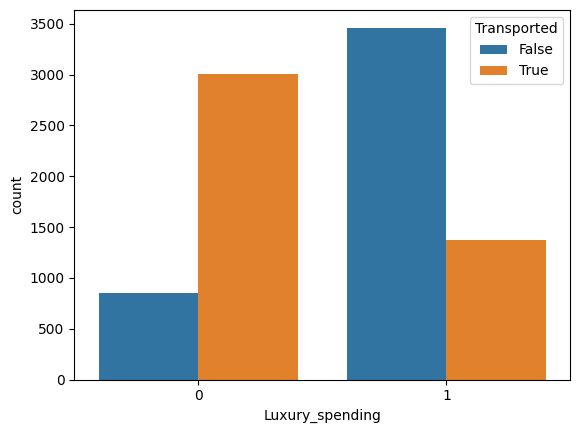

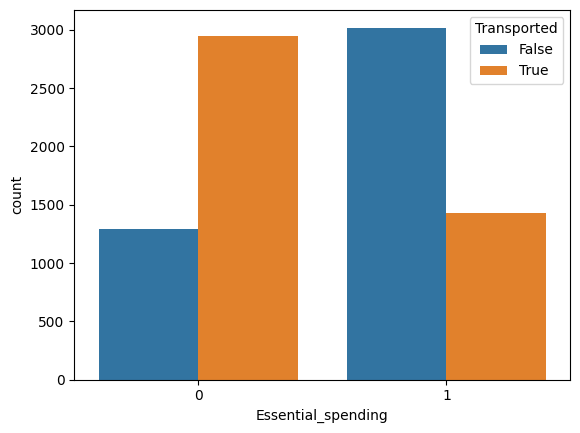

In [926]:
print(train.groupby(['Luxury_spending', 'Essential_spending'])['Transported'].mean())
sns.countplot(x=train['Luxury_spending'], hue=train['Transported'])
plt.show()
sns.countplot(x=train['Essential_spending'], hue=train['Transported'])
plt.show()

### PassengerId -> group, group_size

In [927]:
train['Group'] = train['PassengerId'].apply(lambda x: (x.split('_'))[0])
train['Group_size'] = train.groupby(['Group'])['Group'].transform('count')
train['Solo'] = (train['Group_size'] == 1).astype(int)

test['Group'] = test['PassengerId'].apply(lambda x: (x.split('_'))[0])
test['Group_size'] = test.groupby(['Group'])['Group'].transform('count')
test['Solo'] = (test['Group_size'] == 1).astype(int)

<Axes: xlabel='Group_size', ylabel='count'>

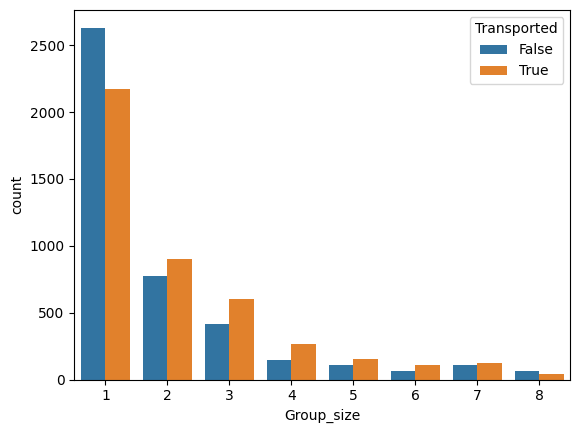

In [928]:
sns.countplot(x=train['Group_size'], hue=train['Transported'])

<Axes: xlabel='Solo', ylabel='count'>

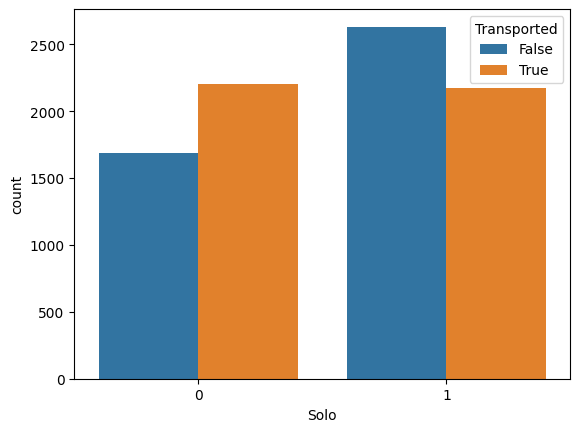

In [929]:
sns.countplot(x=train['Solo'], hue=train['Transported'])

### Cabin -> Cabin_deck, Cabin_num, Cabin_side

In [930]:
train['Cabin'].head(5)

0    B/0/P
1    F/0/S
2    A/0/S
3    A/0/S
4    F/1/S
Name: Cabin, dtype: str

In [931]:
train['Cabin_deck'] = train.loc[train['Cabin'].notna()]['Cabin'].apply(lambda x:(x.split('/')[0]))
train['Cabin_number'] = train.loc[train['Cabin'].notna()]['Cabin'].apply(lambda x:(int(x.split('/')[1])))
train['Cabin_side'] = train.loc[train['Cabin'].notna()]['Cabin'].apply(lambda x:(x.split('/')[2]))

test['Cabin_deck'] = test.loc[test['Cabin'].notna()]['Cabin'].apply(lambda x:(x.split('/')[0]))
test['Cabin_number'] = test.loc[test['Cabin'].notna()]['Cabin'].apply(lambda x:(int(x.split('/')[1])))
test['Cabin_side'] = test.loc[test['Cabin'].notna()]['Cabin'].apply(lambda x:(x.split('/')[2]))

<Axes: xlabel='Cabin_side', ylabel='count'>

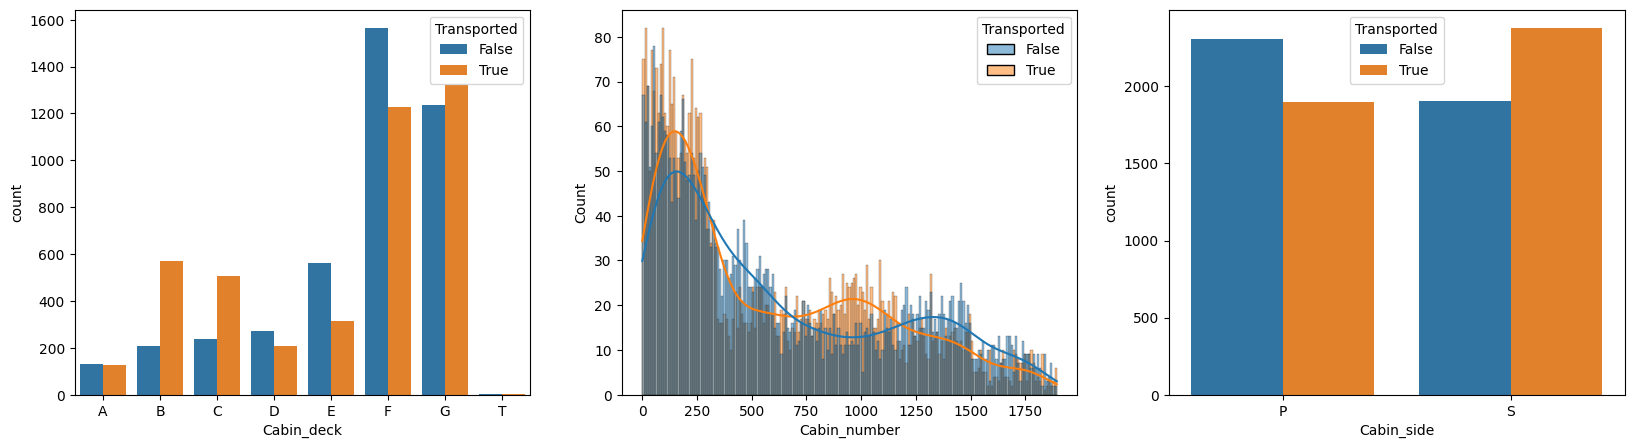

In [932]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.countplot(x=train['Cabin_deck'], hue=train['Transported'], order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'], ax=axes[0])
sns.histplot(x=train['Cabin_number'], hue=train['Transported'], ax=axes[1], binwidth=10, kde=True)
sns.countplot(x=train['Cabin_side'], hue=train['Transported'], ax=axes[2])

Notes:
- kde of cabin_number shows that in specific area were more likely to be transported

### cabin_num -> cabin_region

In [933]:
# Detect KDE crossover points
from scipy.stats import gaussian_kde

data = train[['Cabin_number', 'Transported']].dropna()

kde_true = gaussian_kde((data.loc[data['Transported'] == 1, 'Cabin_number']))
kde_false = gaussian_kde((data.loc[data['Transported'] == 0, 'Cabin_number']))

x_range = np.linspace(data['Cabin_number'].min(), data['Cabin_number'].max(), 1000)
diff = kde_true(x_range) - kde_false(x_range)
kde_points = x_range[np.where(np.diff(np.sign(diff)))].astype(int)
print(kde_points)

[ 297  692 1177]


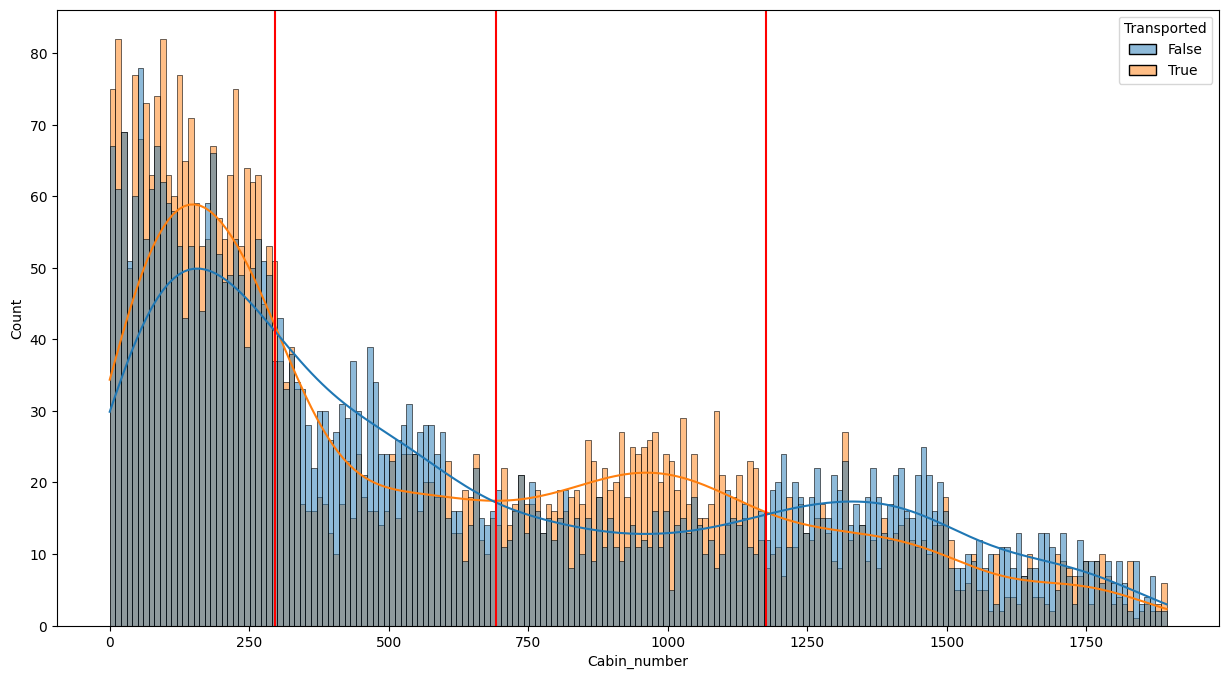

In [934]:
fig = plt.figure(figsize=(15, 8))
sns.histplot(x=train['Cabin_number'], hue=train['Transported'], binwidth=10, kde=True)
for point in kde_points:
    plt.axvline(point, color='red')

In [935]:
train['Cabin_region'] = None
train.loc[train['Cabin_number'] <= 297, 'Cabin_region'] = 'under297'
train.loc[(train['Cabin_number'] > 297) & (train['Cabin_number'] <= 692), 'Cabin_region'] = '297to692'
train.loc[(train['Cabin_number'] > 692) & (train['Cabin_number'] <= 1177), 'Cabin_region'] = '693to1177'
train.loc[train['Cabin_number'] > 1177, 'Cabin_region'] = 'upto1177'

test['Cabin_region'] = None
test.loc[test['Cabin_number'] <= 297, 'Cabin_region'] = 'under297'
test.loc[(test['Cabin_number'] > 297) & (test['Cabin_number'] <= 692), 'Cabin_region'] = '297to692'
test.loc[(test['Cabin_number'] > 692) & (test['Cabin_number'] <= 1177), 'Cabin_region'] = '693to1177'
test.loc[test['Cabin_number'] > 1177, 'Cabin_region'] = 'upto1177'

<Axes: xlabel='Cabin_region', ylabel='count'>

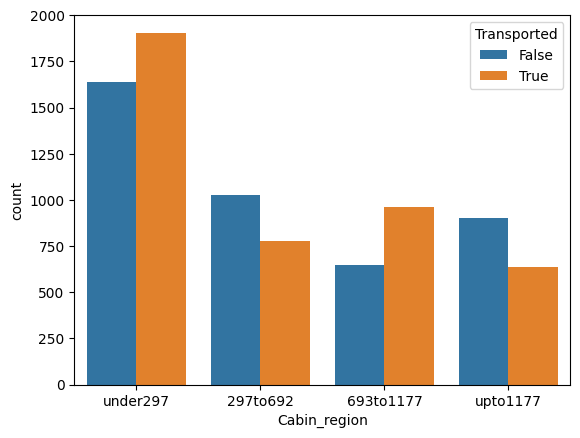

In [936]:
sns.countplot(x=train['Cabin_region'], hue=train['Transported'])

### Name -> Surname, Family_size

In [937]:
train['Name'].head(5)

0      Maham Ofracculy
1         Juanna Vines
2        Altark Susent
3         Solam Susent
4    Willy Santantines
Name: Name, dtype: str

In [938]:
train['Surname'] = train['Name'].str.split(' ').str[-1]
train['Family_size'] = train.groupby(['Surname'])['Surname'].transform('count')

test['Surname'] = test['Name'].str.split(' ').str[-1]
test['Family_size'] = test.groupby(['Surname'])['Surname'].transform('count')

<Axes: xlabel='Family_size', ylabel='count'>

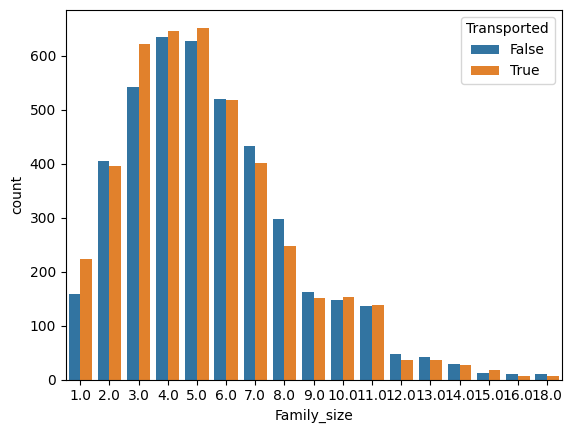

In [939]:
sns.countplot(x=train['Family_size'], hue=train['Transported'])

# 4. Missing values

In [940]:
data = pd.concat([train.drop('Transported', axis=1), test], ignore_index=True)
y_train = train['Transported']

In [941]:
data.isna().sum()

PassengerId             0
HomePlanet            288
CryoSleep             310
Cabin                 299
Destination           274
Age                   270
VIP                   296
RoomService           263
FoodCourt             289
ShoppingMall          306
Spa                   284
VRDeck                268
Name                  294
Age_group             270
Total_expenditure       0
No_spending             0
Luxury_spending         0
Essential_spending      0
Group                   0
Group_size              0
Solo                    0
Cabin_deck            299
Cabin_number          299
Cabin_side            299
Cabin_region          299
Surname               294
Family_size           294
dtype: int64

<Axes: >

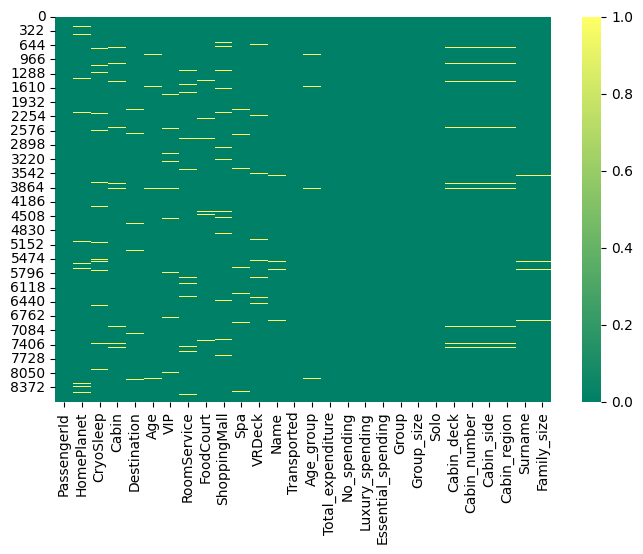

In [942]:
fig = plt.figure(figsize=(8, 5))
sns.heatmap(train.isna(), cmap='summer')

## Missing Age

In [943]:
data['Age'].isna().sum()

np.int64(270)

- Hypothesis: 
1. VRDeck users are likely to be younger passengers. (young people tend to prefer VR) => X
2. Solo passengers tend to be older (X) (Generally, younger people are less likely to travel alone.) => X
3. PActive passengers (not in CryoSleep) with zero spending are likely to be minors. (young children often do not have personal funds to spend.) => O
4. 

#### Hypothesis 1

In [944]:
data.groupby(data['VRDeck'] > 0)['Age'].agg(['mean', 'std', 'count'])

,mean,std,count
VRDeck,,,
False,27.067203,14.926634,8333
True,32.024960,12.678160,4367


**hypothesis 1 is not True**

#### Hypothesis 2

<Axes: xlabel='Age', ylabel='Count'>

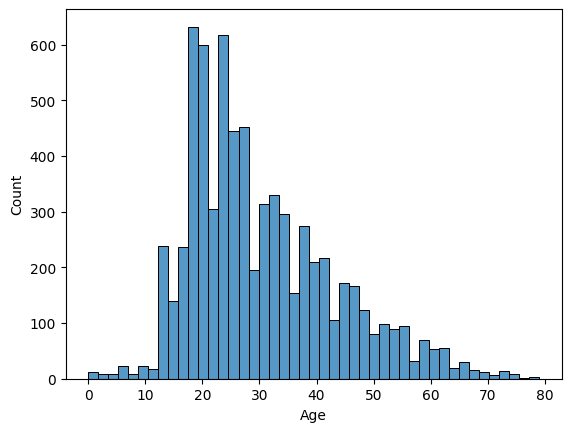

In [945]:
solo_age = data.loc[data['Solo'] == 1]['Age']
sns.histplot(x = solo_age)

In [946]:
data.groupby(['Solo'])['Age'].agg(['mean', 'std', 'count', 'min'])

,mean,std,count,min
Solo,,,,
0,26.714060,15.891294,5697,0.0
1,30.446095,12.795630,7003,0.0


**hypothesis 2 is not True**

#### Hypothesis 3

In [947]:
age_gb = data.groupby(['No_spending', 'CryoSleep'])['Age'].agg(['mean', 'std', 'count'])

<Axes: xlabel='Age', ylabel='Count'>

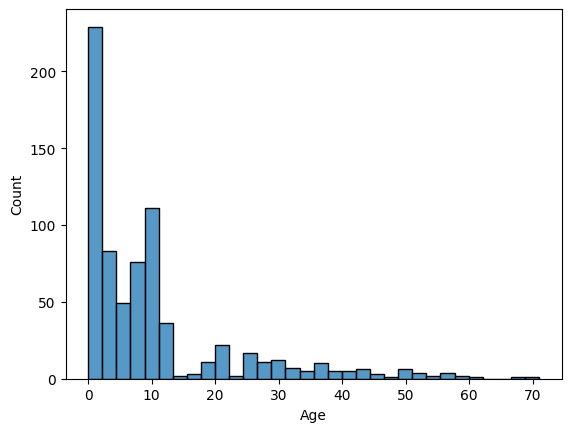

In [948]:
No_spending_age = data.loc[(data['No_spending'] == 1) & (data['CryoSleep'] == 0)]['Age']
sns.histplot(x=No_spending_age)

**hypothesis 3 is True**

So we can fill null with No_spending, CryoSleep



In [949]:
bef = data['Age'].isna().sum()

data.loc[(data['No_spending'] == 1) & (data['CryoSleep'] == 0) & (data['Age'].isna()), 'Age'] = 0

aft = data['Age'].isna().sum()
print(f'age before: {bef}, age after: {aft}')

age before: 270, age after: 257


then fill null of age with groupby

In [950]:
age_gb = data.groupby(['HomePlanet', 'Destination', 'Solo', 'Cabin_deck'])['Age']
age_gb.median().unstack().fillna(0)

Cabin_deck                        A     B     C     D     E     F     G     T
HomePlanet Destination   Solo                                                
Earth      55 Cancri e   0      0.0   0.0   0.0   0.0  25.0  20.5   8.0   0.0
                         1      0.0   0.0   0.0   0.0  28.5  24.0  23.0   0.0
           PSO J318.5-22 0      0.0   0.0   0.0   0.0  24.0  24.0  18.5   0.0
                         1      0.0   0.0   0.0   0.0  31.0  24.0  24.0   0.0
           TRAPPIST-1e   0      0.0   0.0   0.0   0.0  23.0  26.0  15.0   0.0
                         1      0.0   0.0   0.0   0.0  25.0  24.0  25.0   0.0
Europa     55 Cancri e   0     34.0  30.0  32.5  28.5  32.0   0.0   0.0  35.5
                         1     34.5  35.0  35.0  31.5  36.0   0.0   0.0   0.0
           PSO J318.5-22 0     27.5  32.0  29.5   0.0   0.0   0.0   0.0   0.0
                         1      0.0   0.0  34.5   0.0   0.0   0.0   0.0   0.0
           TRAPPIST-1e   0     32.5  31.0  31.0  32.5  31.0   0.0   0.0  47.0
                         1     35.0  33.5  35.0  34.0  32.0   0.0   0.0  35.0
Mars       55 Cancri e   0      0.0   0.0   0.0  29.0  21.0  20.0   0.0   0.0
                         1      0.0   0.0   0.0  28.0  24.0  27.0   0.0   0.0
           PSO J318.5-22 0      0.0   0.0   0.0  38.0  31.0  35.0   0.0   0.0
                         1      0.0   0.0   0.0  34.0  50.0  32.0   0.0   0.0
           TRAPPIST-1e   0      0.0   0.0   0.0  30.0  27.0  23.0   0.0   0.0
                         1      0.0   0.0   0.0  32.0  29.0  30.0   0.0   0.0

In [951]:
bef = data.isna()['Age'].sum()

null_cols = data.loc[data['Age'].isna()].index
data.loc[null_cols, 'Age'] = age_gb.transform(lambda x: x.fillna(x.median()))[null_cols]

aft = data.isna()['Age'].sum()

print(f'age before: {bef}, age after: {aft}')

age before: 257, age after: 18


rest of missing value will filled with 0 (mode)

In [952]:
bef = data.isna()['Age'].sum()
data['Age'] = data['Age'].fillna(data['Age'].mode()[0])
aft = data.isna()['Age'].sum()

print(f'age before: {bef}, age after: {aft}')


age before: 18, age after: 0


Let's update "Age_group"

In [953]:
bef = data.isna()['Age_group'].sum()

data['Age_group'] = None
data.loc[data['Age'] < 19, 'Age_group'] = 'under19'
data.loc[(data['Age'] >= 19) & (data['Age'] <= 40), 'Age_group'] = '19to40'
data.loc[data['Age'] > 40, 'Age_group'] = "over40"

aft = data.isna()['Age_group'].sum()
print(f'age_group before: {bef}, age_group after: {aft}')

age_group before: 270, age_group after: 0


## Missing expenditure

In [954]:
data[expenditure].isna().sum()

RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
dtype: int64

- Hypothesis
1. Passengers in CryoSleep did't spend their money (They can't use it because they sleep)

 #### Hypothesis 1

In [955]:
data.groupby(['CryoSleep'])['Total_expenditure'].agg(['mean', 'count'])

,mean,count
CryoSleep,,
False,2247.914841,8079
True,0.000000,4581


Hypothesis 1 is True

So we can fill missing of expenditures with 'Cryosleep'

In [956]:
bef = data[expenditure].isna().sum()

for exp in expenditure:
    data.loc[data['CryoSleep'] == 1, exp] = 0
    
aft = data[expenditure].isna().sum()

print(f'before: {bef}, after: {aft}')

before: RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
dtype: int64, after: RoomService     170
FoodCourt       180
ShoppingMall    175
Spa             177
VRDeck          177
dtype: int64


In [957]:
data.loc[data['CryoSleep'] == 1, 'Total_expenditure'] = 0

#### The remaining missing values will be filled with 0 (& Total_expenditure, No_spending)

In [958]:
for exp in expenditure:
    data[exp] = data[exp].fillna(data[exp].mode()[0])

# update total_expenditure & No_spending
data['Total_expenditure'] = data[expenditure].sum(axis=1)
data['No_spending'] = (data['Total_expenditure'] == 0).astype(int)

In [959]:
data[expenditure].isna().sum()

RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

#### update Luxury, Essential

In [960]:
data['Luxury_spending'] = (data[luxury].sum(axis=1) != 0).astype(int)
data['Essential_spending'] = (data[essential].sum(axis=1 != 0)).astype(int)

## Missing HomePlanet & Destination

In [961]:
data[['HomePlanet', 'Destination']].isna().sum()

HomePlanet     288
Destination    274
dtype: int64

### Missing HomePlanet

- Hypothesis
1. If Destination is same, HomePlanet is same too
2. If Group is same, HomePlanet is same too
3. passengers who are in same cabin_deck come from same HomePlanet
4. Passengers who have same surname (family) are from same HomePlanet

#### Hypothesis 1

<Axes: xlabel='HomePlanet', ylabel='Destination'>

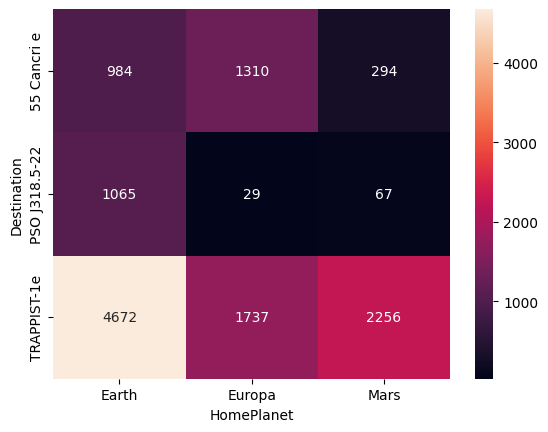

In [962]:
planet_gb = data.groupby(['Destination', 'HomePlanet'])['HomePlanet'].count().unstack().fillna(0)
sns.heatmap(planet_gb, annot=True, fmt='g')

1. Passengers go to PSOJ319.5-22 tend to be from Earth

In [963]:
bef = data['HomePlanet'].isna().sum()

mask = (data['HomePlanet'].isna()) & (data['Destination'] == 'PSO J318.5-22')
data.loc[mask, 'HomePlanet'] = data.loc[mask, 'HomePlanet'].fillna('Earth')

aft = data['HomePlanet'].isna().sum()
print(f'bef = {bef}, aft = {aft}')

bef = 288, aft = 265


#### Hypothesis 2

<Axes: xlabel='None', ylabel='count'>

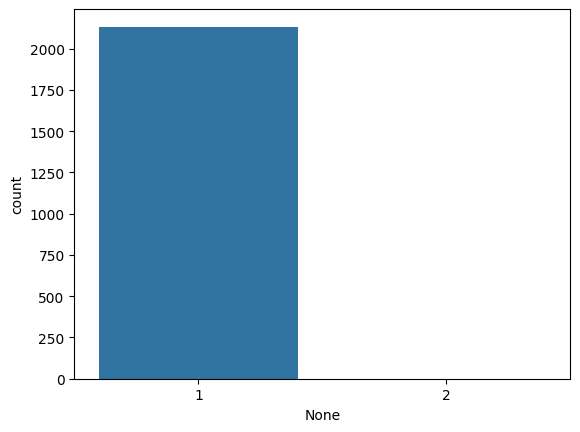

In [964]:
planet_gb = data.loc[data['Group_size'] > 1].groupby(['Group', 'HomePlanet'])['HomePlanet'].count().unstack().fillna(0)
sns.countplot(x=planet_gb.astype(bool).sum(axis=1))

Hypothesis 2 is True

In [965]:
bef = data['HomePlanet'].isna().sum()

planet_gb = data.loc[data['Group_size'] > 1].groupby(['Group', 'HomePlanet'])['HomePlanet'].count().unstack().fillna(0)

planet_index = data.loc[data['HomePlanet'].isna()][data.loc[data['HomePlanet'].isna()]['Group'].isin(planet_gb.index)].index
data.loc[planet_index, 'HomePlanet'] = data.loc[planet_index, 'Group'].map(lambda x: planet_gb.idxmax(axis=1)[x])

aft = data['HomePlanet'].isna().sum()
print(f'bef = {bef}, aft = {aft}')

bef = 265, aft = 143


#### Hypothesis 3

<Axes: xlabel='HomePlanet', ylabel='Cabin_deck'>

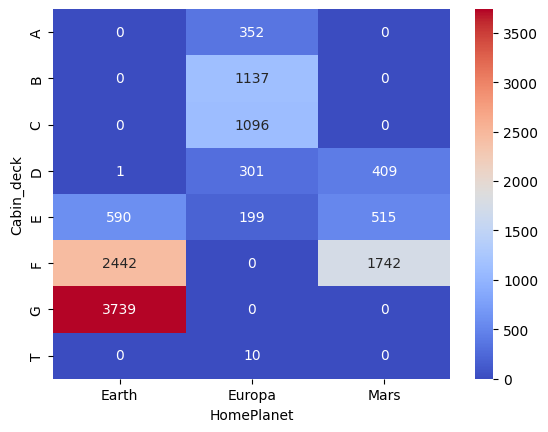

In [966]:
planet_gb = data.groupby(['Cabin_deck', 'HomePlanet'])['HomePlanet'].count().unstack().fillna(0)
sns.heatmap(planet_gb, annot=True, fmt='g', cmap='coolwarm')

- Passengers in Deck 'A', 'B', 'C' are likely to be from Europa
- Passengers in Deck 'F' are likely to be from Earth 

In [967]:
bef = data['HomePlanet'].isna().sum()

mask1 = data['Cabin_deck'].isin(['A', 'B', 'C'])
mask2 = (data['Cabin_deck'] == 'G')
data.loc[mask1, 'HomePlanet'] = data.loc[mask1, 'HomePlanet'].fillna('Europa')
data.loc[mask2, 'HomePlanet'] = data.loc[mask2, 'HomePlanet'].fillna('Earth')

aft = data['HomePlanet'].isna().sum()
print(f'bef = {bef}, aft = {aft}')

bef = 143, aft = 89


#### Hypotehsis4

<Axes: xlabel='None', ylabel='count'>

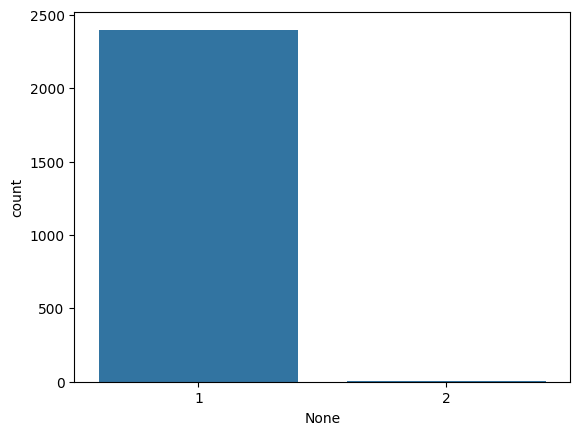

In [968]:
planet_gb = data.groupby(['Surname', 'HomePlanet'])['HomePlanet'].count().unstack().fillna(0)
sns.countplot(x=planet_gb.astype(bool).sum(axis=1))

Hypothesis4 is true

In [969]:
bef = data['HomePlanet'].isna().sum()

planet_index = data.loc[data['HomePlanet'].isna()][data.loc[data['HomePlanet'].isna(), 'Surname'].isin(planet_gb.index)].index
data.loc[planet_index, 'HomePlanet'] = data.loc[planet_index, 'Surname'].map(lambda x: planet_gb.idxmax(axis=1)[x])

aft = data['HomePlanet'].isna().sum()
print(f'bef = {bef}, aft = {aft}')

bef = 89, aft = 10


#### Rest of Missing HomePlanet

In [970]:
data.loc[data['HomePlanet'].isna()][['Destination', 'Cabin_deck']]

,Destination,Cabin_deck
2274,TRAPPIST-1e,D
2631,TRAPPIST-1e,F
3091,TRAPPIST-1e,F
4548,TRAPPIST-1e,F
5762,TRAPPIST-1e,F
8969,TRAPPIST-1e,E
10583,TRAPPIST-1e,D
11913,TRAPPIST-1e,E
12551,TRAPPIST-1e,F
12725,TRAPPIST-1e,D


most of passengers go to TRAPPIST-1e are from Earth

**But, remember that Passengers to stay deck 'A','B','C','D' aren't from Earth**

In [971]:
bef = data['HomePlanet'].isna().sum()

data.loc[(data['HomePlanet'].isna()) & (data['Cabin_deck'] != 'D'), 'HomePlanet'] = 'Earth'
# passengers to stay deck 'D' may be from mars
data['HomePlanet'] = data['HomePlanet'].fillna('Mars')

aft = data['HomePlanet'].isna().sum()
print(f'bef = {bef}, aft = {aft}')

bef = 10, aft = 0


### Missing Destination

- Hypothesis
1. If HomePlanet is same, Destination is same too
2. If group is same, Destination is same
3. If Surname is same(Family), Destination is same
4. If Cabin_deck is same, Destination is same

#### Hypothesis 1

<Axes: xlabel='Destination', ylabel='HomePlanet'>

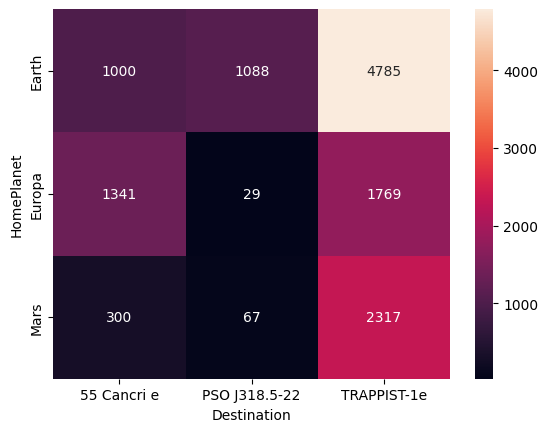

In [972]:
des_gb = data.groupby(['HomePlanet', 'Destination'])['Destination'].count().unstack().fillna(0)
sns.heatmap(des_gb, annot=True, fmt='g')

1. Passengers from Mars and Earth are likely to go to TRAPPIST-1e

#### Hypothesis 2

<Axes: xlabel='None', ylabel='count'>

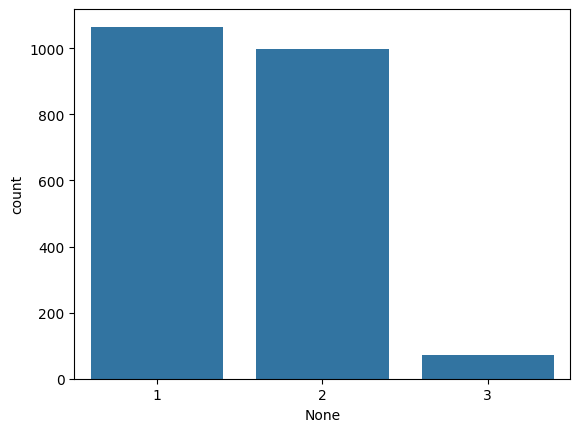

In [973]:
des_gb = data.loc[data['Group_size'] > 1].groupby(['Group', 'Destination'])['Destination'].count().unstack().fillna(0)
sns.countplot(x=des_gb.astype(bool).sum(axis=1))

Hypothesis 2 is not True

In [974]:
des_gb

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
Group,,,
0003,0.0,0.0,2.0
0006,0.0,0.0,2.0
0008,2.0,0.0,1.0
0017,1.0,0.0,1.0
0020,2.0,1.0,3.0
...,...,...,...
9266,0.0,0.0,2.0
9267,0.0,0.0,2.0
9272,0.0,0.0,2.0


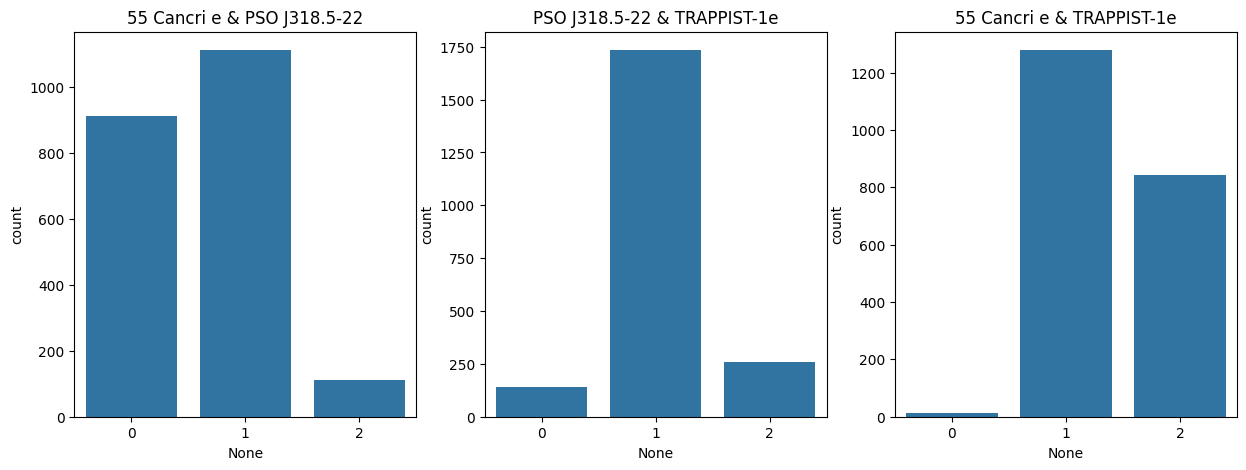

In [975]:
des_gb = data.loc[data['Group_size'] > 1].groupby(['Group', 'Destination'])['Destination'].count().unstack().fillna(0)
des_gb1 = des_gb[['55 Cancri e', 'PSO J318.5-22']]
des_gb2 = des_gb[['PSO J318.5-22', 'TRAPPIST-1e']]
des_gb3 = des_gb[['55 Cancri e', 'TRAPPIST-1e']]

gb_list = [des_gb1, des_gb2, des_gb3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, gb in enumerate(gb_list):
    sns.countplot(x=gb.astype(bool).sum(axis=1), ax=axes[i])
    axes[i].set_title(f'{gb.columns[0]} & {gb.columns[1]}')

But among passengers going to PSO or TRA, if they are in the same group, they are highly likely to go to one of the two.

#### Hypothesis 3

<Axes: xlabel='None', ylabel='count'>

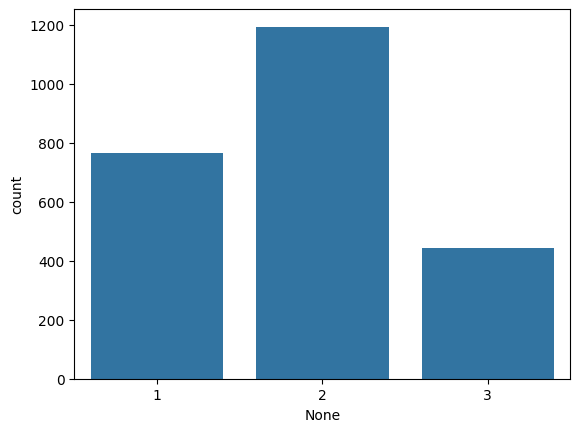

In [976]:
des_gb = data.groupby(['Surname', 'Destination'])['Destination'].count().unstack().fillna(0)
sns.countplot(x=des_gb.astype(bool).sum(axis=1))

Hypothesis 3 is not True

### Hypothesis 4

<Axes: xlabel='Cabin_deck', ylabel='Destination'>

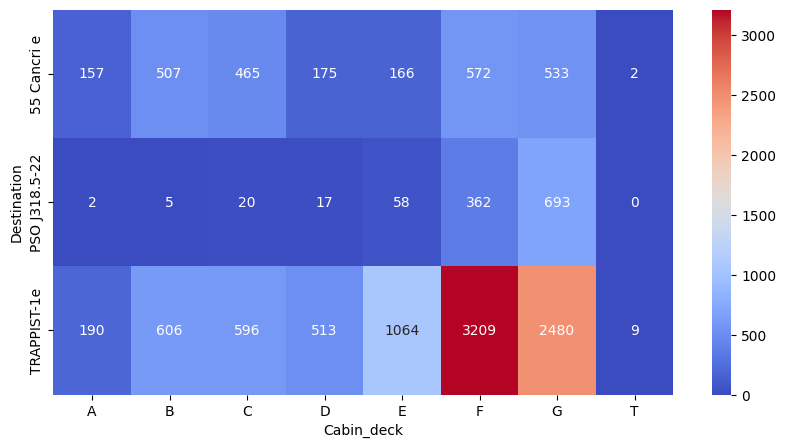

In [977]:
fig = plt.figure(figsize=(10, 5))
des_gb = data.groupby(['Cabin_deck', 'Destination'])['Destination'].count().unstack().fillna(0)
sns.heatmap(des_gb.T, annot=True, fmt='g', cmap='coolwarm')

- passenger staying in deck 'D', 'E', 'F', and 'G' are likely to go TRAPPIST-1e
- passenger staying in deck 'A', 'B', 'C', and 'D' are **unlikely** to go PSOJ319.5-22

Let's fill Missing Destination

In [978]:
data['Destination'].value_counts()

Destination
TRAPPIST-1e      8871
55 Cancri e      2641
PSO J318.5-22    1184
Name: count, dtype: int64

In [979]:
# Hypothesis 2

bef = data['Destination'].isna().sum()

des_gb = data.loc[data['Group_size'] > 1].groupby(['Group', 'Destination'])['Destination'].count().unstack().fillna(0)
des_gb = des_gb.loc[des_gb['55 Cancri e'] == 0][['PSO J318.5-22', 'TRAPPIST-1e']]
des_index = data.loc[data['Destination'].isna()][data.loc[data['Destination'].isna(), 'Group'].isin(des_gb.index)].index
data.loc[des_index, 'Destination'] = data.loc[des_index, 'Group'].map(lambda x: des_gb.idxmax(axis=1)[x])

aft = data['Destination'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 274, aft: 196


In [980]:
# Hypothesis 1
bef = data['Destination'].isna().sum()

mask = (data['Destination'].isna()) & (data['HomePlanet'].isin(['Mars', 'Earth']))
data.loc[mask, 'Destination'] = data.loc[mask, 'Destination'].fillna('TRAPPIST-1e')

aft = data['Destination'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 196, aft: 46


In [981]:
# Hypothesis 4
bef = data['Destination'].isna().sum()

mask = (data['Destination'].isna()) & (data['Cabin_deck'].isin(['D', 'E', 'F', 'G']))
data.loc[mask, 'Destination'] = data.loc[mask, 'Destination'].fillna('TRAPPIST-1e')

aft = data['Destination'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 46, aft: 38


In [982]:
bef = data['Destination'].isna().sum()
data['Destination'] = data['Destination'].fillna('TRAPPIST-1e')

aft = data['Destination'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 38, aft: 0


In [983]:
data['Destination'].value_counts()

Destination
TRAPPIST-1e      9134
55 Cancri e      2641
PSO J318.5-22    1195
Name: count, dtype: int64

## Missing Cabin (Cabin_deck, Cabin_number, Cabin_side, Cabin_region)

In [984]:
data[['Cabin_deck', 'Cabin_number', 'Cabin_side', 'Cabin_region']].isna().sum()

Cabin_deck      299
Cabin_number    299
Cabin_side      299
Cabin_region    299
dtype: int64

- Hypothesis 
1. Group and Cabin_number have a strong relationship (as does the Cabin deck)"

Text(0.5, 1.0, 'Group and Cabin_number(hue=Cabin_deck)')

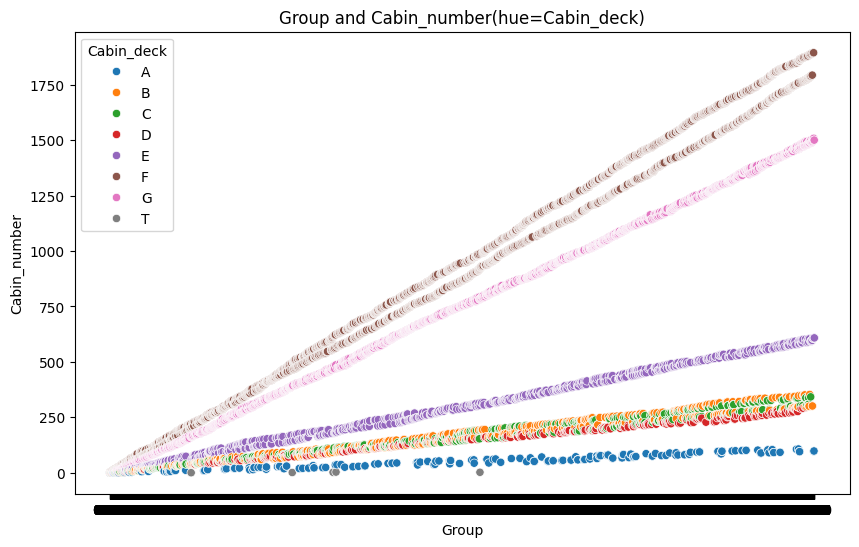

In [985]:
fig = plt.figure(figsize=(10, 6))
sns.scatterplot(x=train['Group'], y=train['Cabin_number'], hue=train['Cabin_deck'],
                hue_order=['A','B','C','D','E','F','G','T'])
plt.title('Group and Cabin_number(hue=Cabin_deck)')

**Hypothesis 1 is True!**

"Group" and "Cabin_number" has linear relation

So we can use this information to fill Missing values

### Cabin_side

- Hypotehsis 
1. If group is same, Cabin_side is same too
2. Groups of two or more people with the same surname tend to be assigned to the same side of the cabin

<Axes: xlabel='None', ylabel='count'>

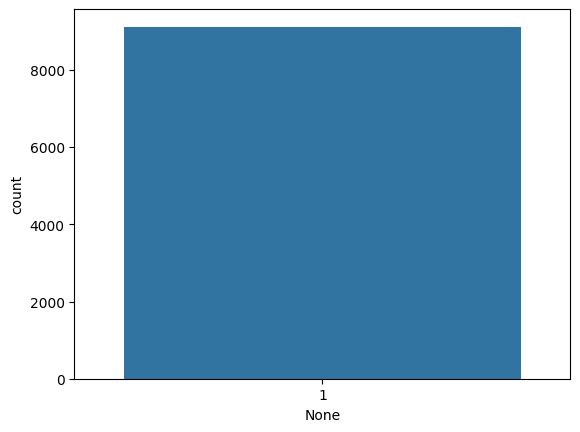

In [986]:
side_gb = data.groupby(['Group', 'Cabin_side'])['Cabin_side'].count().unstack().fillna(0)
sns.countplot(x=side_gb.astype(bool).sum(axis=1))

Hypothesis 1 is True

In [987]:
bef = data['Cabin_side'].isna().sum()

side_map = side_gb.idxmax(axis=1)
data['Cabin_side'] = data['Cabin_side'].fillna(data['Group'].map(side_map))

aft = data['Cabin_side'].isna().sum()

print(f'bef: {bef}, aft: {aft}')

bef: 299, aft: 162


<Axes: xlabel='None', ylabel='Count'>

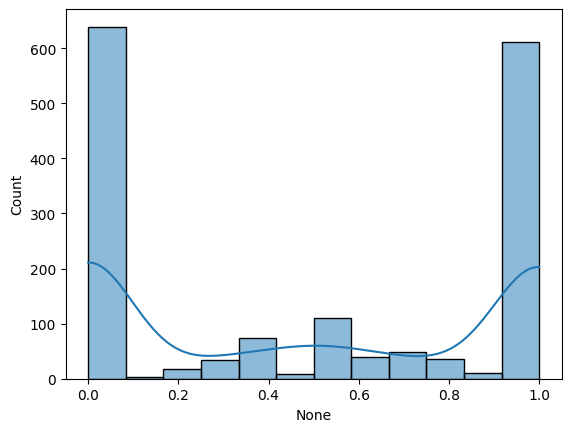

In [988]:
side_gb = data[data['Group_size'] > 1].groupby(['Surname', 'Cabin_side'])['Cabin_side'].count().unstack().fillna(0)
ratio = side_gb['P'] / (side_gb['P'] + side_gb['S'])
sns.histplot(x=ratio, kde=True)

In [989]:
percentage = np.round(len(ratio.loc[(ratio == 0) | (ratio == 1)]) / len(ratio), 4)
print(percentage)

0.767


Hypothesis 2 is True

In [990]:
bef = data['Cabin_side'].isna().sum()

side_index = data.loc[(data['Cabin_side'].isna())][data[data['Cabin_side'].isna()]['Surname'].isin(side_gb.index)].index
data.loc[side_index, 'Cabin_side'] = data.iloc[side_index]['Surname'].map(lambda x: side_gb.idxmax(axis=1)[x])

aft = data['Cabin_side'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 162, aft: 66


We consider rest of Missing Cabin_side as outlier

In [991]:
bef = data['Cabin_side'].isna().sum()

data['Cabin_side'] = data['Cabin_side'].fillna('Z')

aft = data['Cabin_side'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 66, aft: 0


### Cabin_deck

- Hypothesis
1. if Homeplanet is same, Cabin_deck may be same
2. if destination is same, Cabin_deck may be same
3. if Surname is same(They are family), Cabin_deck may be same
4. Group is same, Cabin_deck is same too

<Axes: xlabel='Cabin_deck', ylabel='HomePlanet'>

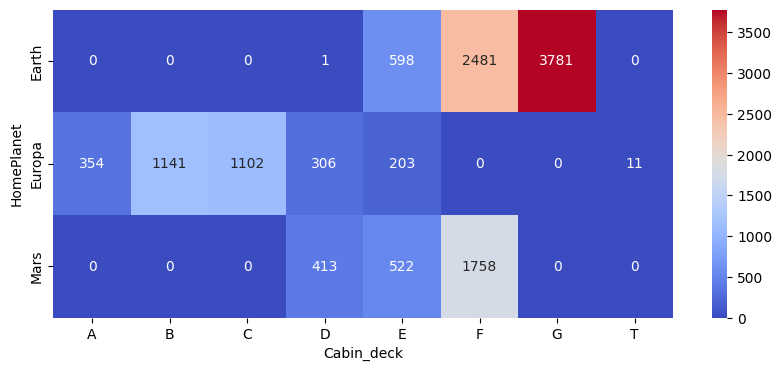

In [992]:
fig = plt.figure(figsize=(10, 4))
deck_gb = data.groupby(['HomePlanet', 'Cabin_deck'])['Cabin_deck'].count().unstack().fillna(0)
sns.heatmap(deck_gb, cmap='coolwarm', annot=True, fmt='g')

The heatmap indicate that
- passenger from Earth tend to be in Cabin deck 'G'
- passenger from Europa tend to be in Cabin deck 'B', 'C'
- passenger from Mars tend to be in Cabin deck 'F'

<Axes: xlabel='Cabin_deck', ylabel='Destination'>

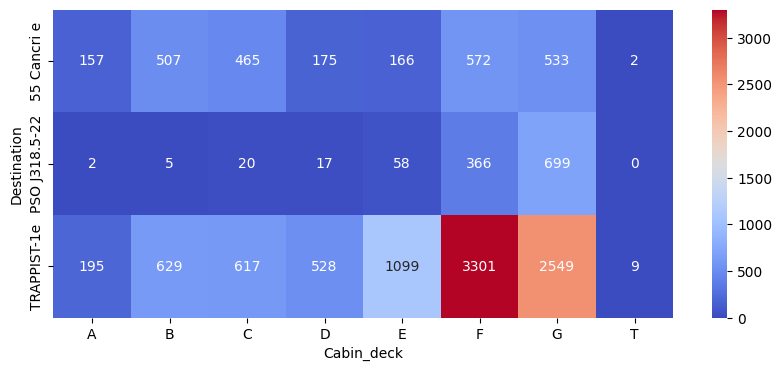

In [993]:
fig = plt.figure(figsize=(10, 4))
deck_gb = data.groupby(['Destination', 'Cabin_deck'])['Cabin_deck'].count().unstack().fillna(0)
sns.heatmap(deck_gb, cmap='coolwarm', annot=True, fmt='g')


The heatmap indicate that
- passenger go to PSO.. tend to be Cabin deck 'F', 'G'
- passenger go to TRA.. tend to be Cabin deck 'E', 'F'

<Axes: xlabel='None', ylabel='count'>

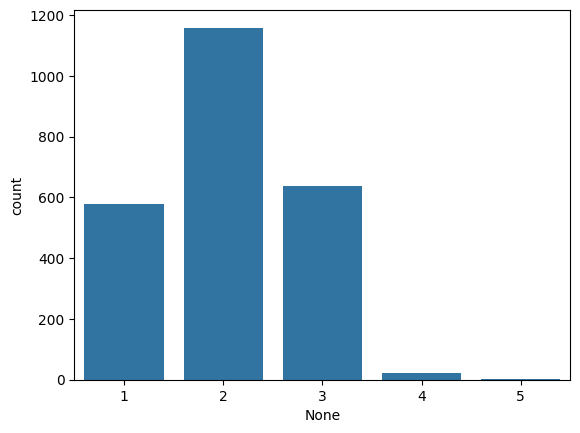

In [994]:
deck_gb = data.groupby(['Surname', 'Cabin_deck'])['Cabin_deck'].count().unstack().fillna(0)
sns.countplot(x=deck_gb.astype(bool).sum(axis=1))

Hypothesis 3 is False

<Axes: xlabel='None', ylabel='count'>

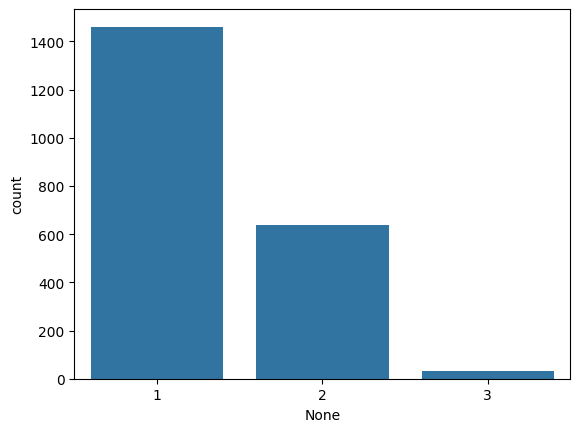

In [995]:
deck_gb = data[data['Group_size'] > 1].groupby(['Group', 'Cabin_deck'])['Cabin_deck'].count().unstack().fillna(0)
sns.countplot(x=deck_gb.astype(bool).sum(axis=1))

Hypothesis 4 may be True

So let's fill Missing values

In [996]:
# fill null with group and Cabin_deck
bef = data['Cabin_deck'].isna().sum()

deck_index = data[data['Cabin_deck'].isna()][data[data['Cabin_deck'].isna()]['Group'].isin(deck_gb.index)].index
data.loc[deck_index, 'Cabin_deck'] = data.loc[deck_index, 'Group'].map(lambda x: deck_gb.idxmax(axis=1)[x])

aft = data['Cabin_deck'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 299, aft: 162


In [997]:
# fill rest of null with groupby
bef = data['Cabin_deck'].isna().sum()

deck_gb = data.groupby(['HomePlanet', 'Destination', 'Solo', 'Cabin_deck'])['Cabin_deck'].count().unstack().fillna(0)
deck_index = data[data['Cabin_deck'].isna()][data[data['Cabin_deck'].isna()].isin(deck_gb.index)].index
data.loc[deck_index, 'Cabin_deck'] = data.groupby(['HomePlanet', 'Destination', 'Solo'])['Cabin_deck'].transform(lambda x: x.fillna(pd.Series.mode(x)[0]))[deck_index]

aft = data['Cabin_deck'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 162, aft: 0


### Cabin_number

In [998]:
from sklearn.linear_model import LinearRegression
bef = data['Cabin_number'].isna().sum()

deck_list = ['A','B','C','D','E','F','G']
for deck in deck_list:
    reg = LinearRegression()

    X_train = data.loc[(data['Cabin_number'].notna()) & (data['Cabin_deck'] == deck)]['Group']
    y_train = data.loc[(data['Cabin_number'].notna()) & (data['Cabin_deck'] == deck)]['Cabin_number']

    X_test = data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck)]['Group']

    reg.fit(X_train.to_numpy().reshape(-1, 1), y_train.to_numpy().reshape(-1, 1))
    preds = reg.predict(X_test.to_numpy().reshape(-1, 1))
    data.loc[(data['Cabin_number'].isna()) & (data['Cabin_deck'] == deck), 'Cabin_number'] = preds.astype(int)

aft = data['Cabin_number'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 299, aft: 0


In [999]:
data

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,Essential_spending,Group,Group_size,Solo,Cabin_deck,Cabin_number,Cabin_side,Cabin_region,Surname,Family_size
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,...,0,0001,1,1,B,0.0,P,under297,Ofracculy,1.0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,...,34,0002,1,1,F,0.0,S,under297,Vines,4.0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,...,3576,0003,2,0,A,0.0,S,under297,Susent,6.0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,...,1654,0003,2,0,A,0.0,S,under297,Susent,6.0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,...,221,0004,1,1,F,1.0,S,under297,Santantines,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,...,0,9266,2,0,G,1496.0,S,upto1177,Peter,4.0
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,...,864,9269,1,1,G,1502.0,Z,None,Scheron,2.0
12967,9271_01,Mars,True,D/296/P,55 Cancri e,28.0,False,0.0,0.0,0.0,...,0,9271,1,1,D,296.0,P,under297,Pore,4.0
12968,9273_01,Europa,False,D/297/P,TRAPPIST-1e,24.0,False,0.0,2680.0,0.0,...,2680,9273,1,1,D,297.0,P,under297,Conale,5.0


### Cabin_region

Now let's update Cabin_region

In [1000]:
bef = data['Cabin_region'].isna().sum()

data['Cabin_region'] = None
data.loc[data['Cabin_number'] <= 297, 'Cabin_region'] = 'under297'
data.loc[(data['Cabin_number'] > 297) & (data['Cabin_number'] <= 692), 'Cabin_region'] = '297to692'
data.loc[(data['Cabin_number'] > 692) & (data['Cabin_number'] <= 1177), 'Cabin_region'] = '693to1177'
data.loc[data['Cabin_number'] > 1177, 'Cabin_region'] = 'upto1177'

aft = data['Cabin_region'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 299, aft: 0


## Missing CryoSleep

In [1017]:
print(data['CryoSleep'].isna().sum())

0


- Hypothesis
1. Passengers with any amount of spending are not in CryoSleep

<Axes: xlabel='CryoSleep', ylabel='No_spending'>

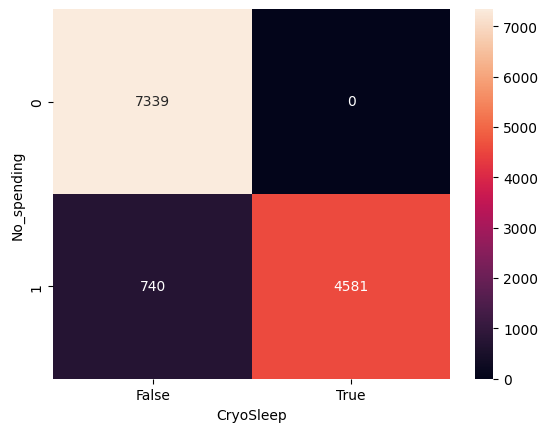

In [1012]:
cryo_gb = data.groupby(['No_spending', 'CryoSleep'])['CryoSleep'].count().unstack().fillna(0)
sns.heatmap(cryo_gb, annot=True, fmt='g')

Hypothesis 1 is True

#### Hypothesis 1

In [1016]:
bef = data['CryoSleep'].isna().sum()

cryo_index = data.loc[data['CryoSleep'].isna()][data.loc[data['CryoSleep'].isna()]['No_spending'].isin(cryo_gb.index)].index
data.loc[cryo_index, 'CryoSleep'] = data.loc[cryo_index, 'No_spending'].map(lambda x: cryo_gb.idxmax(axis=1)[x])

aft = data['CryoSleep'].isna().sum()
print(f'bef: {bef}, aft: {aft}')

bef: 310, aft: 0


## Check Missing values

In [1018]:
data.isna().sum()


PassengerId             0
HomePlanet              0
CryoSleep               0
Cabin                 299
Destination             0
Age                     0
VIP                   296
RoomService             0
FoodCourt               0
ShoppingMall            0
Spa                     0
VRDeck                  0
Name                  294
Age_group               0
Total_expenditure       0
No_spending             0
Luxury_spending         0
Essential_spending      0
Group                   0
Group_size              0
Solo                    0
Cabin_deck              0
Cabin_number            0
Cabin_side              0
Cabin_region            0
Surname               294
Family_size           294
dtype: int64

# 5. Preprocessing

we will remove some unnecessary features

In [ ]:
# Splitting the data back into X_train and X_test.
X_train = data.loc[data['PassengerId'].isin(train['PassengerId'].values)].copy()
X_test = data.loc[data['PassengerId'].isin(test['PassengerId'].values)].copy()

In [1041]:
# remove unnecessary features
X_train.drop(['PassengerId', 'Cabin', 'VIP', 'Name', 'Group', 'Group_size', 'Surname'], axis=1, inplace=True)
X_test.drop(['PassengerId', 'Cabin', 'VIP', 'Name', 'Group', 'Group_size', 'Surname'], axis=1, inplace=True)